# Income Classification — Model Training & Evaluation
**ML Assignment 2 | UCI Adult (Census Income) dataset**

In this notebook I train five classification models on the UCI Adult dataset to predict
whether a person earns more than \$50K a year. I evaluate every model with six metrics
(Accuracy, AUC, Precision, Recall, F1, MCC), compare them, and export the trained
pipelines plus a held-out test set for my Streamlit app.


In [1]:
# --- Core imports ---
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (accuracy_score, roc_auc_score, precision_score,
                             recall_score, f1_score, matthews_corrcoef,
                             confusion_matrix, classification_report)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
RANDOM_SEED = 42

MODELS_DIR = Path("models"); MODELS_DIR.mkdir(exist_ok=True)
RESULTS_DIR = Path("results"); RESULTS_DIR.mkdir(exist_ok=True)
print("Environment ready.")


Environment ready.


## 1. Load the dataset

In [2]:
income_df = pd.read_csv("data/adult.csv")
print("Rows, Columns:", income_df.shape)
income_df.head()


Rows, Columns: (32561, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [3]:
# Basic structure and target balance
income_df.info()
print("\nTarget distribution:")
print(income_df["income"].value_counts(normalize=True).round(3))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  31978 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB

Target distribution:
income
<=50K    0.759
>50K     0.241
Name: proportion, dtype: float64


## 2. Exploratory Data Analysis (EDA)
I look at the class balance, missing values, and a couple of relationships that
influence income.

In [4]:
# Missing values per column
missing_counts = income_df.isna().sum()
print("Columns with missing values:")
print(missing_counts[missing_counts > 0])


Columns with missing values:
workclass         1836
occupation        1843
native_country     583
dtype: int64


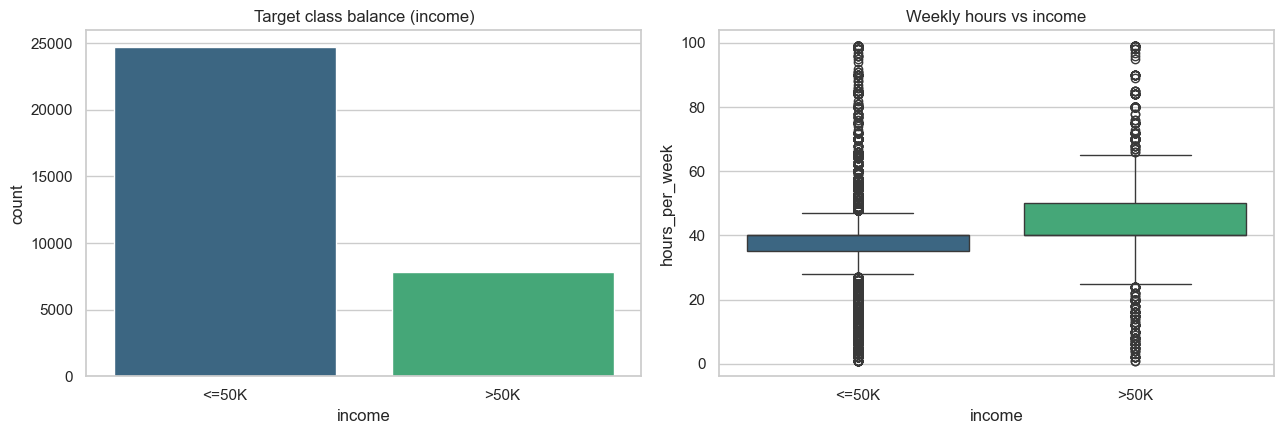

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.countplot(data=income_df, x="income", ax=axes[0], palette="viridis")
axes[0].set_title("Target class balance (income)")

sns.boxplot(data=income_df, x="income", y="hours_per_week", ax=axes[1], palette="viridis")
axes[1].set_title("Weekly hours vs income")
plt.tight_layout(); plt.show()


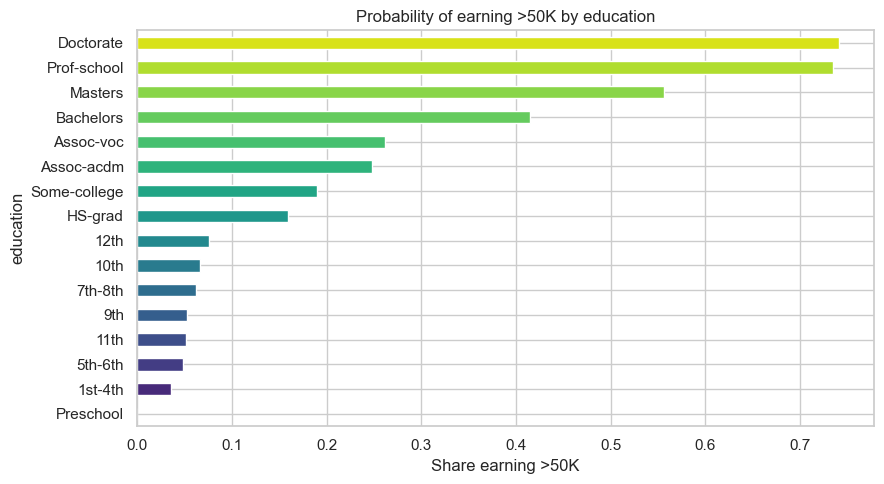

In [6]:
# Income rate across education levels (top categories)
edu_rate = (income_df.assign(high=(income_df["income"] == ">50K").astype(int))
                     .groupby("education")["high"].mean().sort_values())
plt.figure(figsize=(9, 5))
edu_rate.plot(kind="barh", color=sns.color_palette("viridis", len(edu_rate)))
plt.xlabel("Share earning >50K"); plt.title("Probability of earning >50K by education")
plt.tight_layout(); plt.show()


## 3. Preprocessing & train/test split
I separate numeric and categorical attributes, impute missing values, scale the numeric
columns, and one-hot encode the categorical ones. Everything is wrapped in a
`ColumnTransformer` so each model becomes a single, self-contained pipeline.

In [7]:
# Encode target: >50K -> 1, <=50K -> 0
target_series = (income_df["income"] == ">50K").astype(int)
feature_frame = income_df.drop(columns=["income"])

numeric_attrs = ["age", "fnlwgt", "education_num", "capital_gain",
                 "capital_loss", "hours_per_week"]
categorical_attrs = ["workclass", "education", "marital_status", "occupation",
                     "relationship", "race", "sex", "native_country"]

numeric_branch = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])
categorical_branch = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("encode", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])
prep = ColumnTransformer([
    ("num", numeric_branch, numeric_attrs),
    ("cat", categorical_branch, categorical_attrs),
])

X_train, X_test, y_train, y_test = train_test_split(
    feature_frame, target_series, test_size=0.2,
    stratify=target_series, random_state=RANDOM_SEED)
print("Train:", X_train.shape, "| Test:", X_test.shape)


Train: (26048, 14) | Test: (6513, 14)


## 4. Train the five models & compute six metrics
For every model I fit a full pipeline (`preprocessing -> classifier`) and record all six
evaluation metrics on the held-out test set.

In [8]:
model_zoo = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
    "Decision Tree": DecisionTreeClassifier(max_depth=12, random_state=RANDOM_SEED),
    "kNN": KNeighborsClassifier(n_neighbors=15),
    "Naive Bayes": GaussianNB(),
    "Random Forest (Ensemble)": RandomForestClassifier(
        n_estimators=150, max_depth=18, min_samples_leaf=2,
        random_state=RANDOM_SEED, n_jobs=-1),
}

scoreboard = []
for name, estimator in model_zoo.items():
    pipe = Pipeline([("prep", prep), ("model", estimator)])
    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    scoreboard.append({
        "ML Model Name": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_proba),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "MCC": matthews_corrcoef(y_test, y_pred),
    })

    slug = name.split(" (")[0].lower().replace(" ", "_")
    joblib.dump(pipe, MODELS_DIR / f"{slug}.pkl", compress=3)
    print(f"Trained & saved: {name}")


Trained & saved: Logistic Regression


Trained & saved: Decision Tree


Trained & saved: kNN
Trained & saved: Naive Bayes


Trained & saved: Random Forest (Ensemble)


## 5. Comparison table

In [9]:
results_df = pd.DataFrame(scoreboard).set_index("ML Model Name").round(4)
results_df.to_csv(RESULTS_DIR / "metrics.csv")
results_df


,Accuracy,AUC,Precision,Recall,F1,MCC
ML Model Name,,,,,,
Logistic Regression,0.8558,0.9078,0.7406,0.6173,0.6734,0.5858
Decision Tree,0.8503,0.8896,0.7058,0.6486,0.6760,0.5797
kNN,0.8455,0.8909,0.7063,0.6135,0.6567,0.5599
Naive Bayes,0.5382,0.7495,0.3374,0.9528,0.4983,0.3294
Random Forest (Ensemble),0.8672,0.9203,0.7966,0.6020,0.6858,0.6132


In [10]:
best_model = results_df["F1"].idxmax()
print("Best model by F1 score:", best_model)
results_df.style.background_gradient(cmap="Greens")


Best model by F1 score: Random Forest (Ensemble)


,Accuracy,AUC,Precision,Recall,F1,MCC
ML Model Name,,,,,,
Logistic Regression,0.855800,0.907800,0.740600,0.617300,0.673400,0.585800
Decision Tree,0.850300,0.889600,0.705800,0.648600,0.676000,0.579700
kNN,0.845500,0.890900,0.706300,0.613500,0.656700,0.559900
Naive Bayes,0.538200,0.749500,0.337400,0.952800,0.498300,0.329400
Random Forest (Ensemble),0.867200,0.920300,0.796600,0.602000,0.685800,0.613200


## 6. Confusion matrices

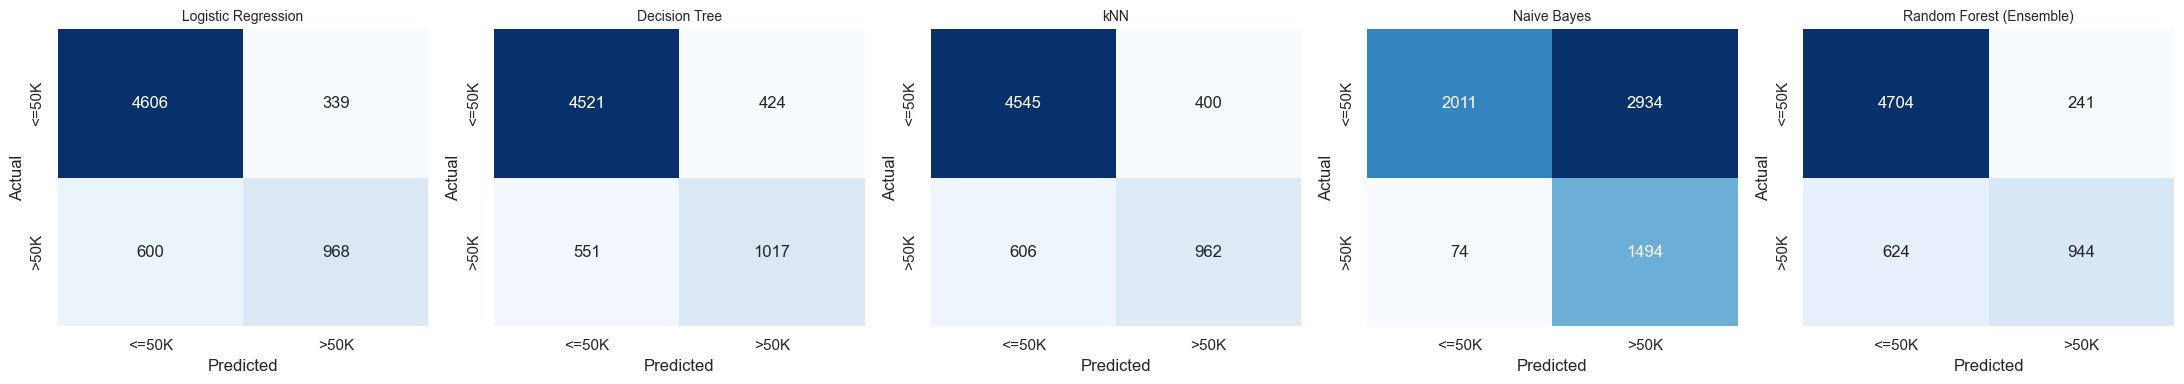

In [11]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, (name, estimator) in zip(axes, model_zoo.items()):
    pipe = joblib.load(MODELS_DIR / f"{name.split(' (')[0].lower().replace(' ', '_')}.pkl")
    cm = confusion_matrix(y_test, pipe.predict(X_test))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["<=50K", ">50K"], yticklabels=["<=50K", ">50K"])
    ax.set_title(name, fontsize=10); ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout(); plt.show()


## 7. Export the test data for the Streamlit app
Only the held-out test set is exported (the free Streamlit tier has limited capacity).
The CSV keeps the raw feature columns plus the original `income` label so the saved
pipelines can preprocess and score it directly in the app.

In [12]:
test_export = X_test.copy()
test_export["income"] = np.where(y_test.values == 1, ">50K", "<=50K")
test_export.to_csv("test_data.csv", index=False)
print("Saved test_data.csv with shape:", test_export.shape)
test_export.head()


Saved test_data.csv with shape: (6513, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
9009,31,Self-emp-inc,117963,Doctorate,16,Never-married,Prof-specialty,Own-child,White,Male,0,0,40,United-States,<=50K
25134,20,NaN,201490,Some-college,10,Never-married,NaN,Own-child,White,Male,0,0,40,United-States,<=50K
16682,78,Self-emp-inc,385242,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,9386,0,45,United-States,>50K
27044,32,Private,164197,Bachelors,13,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,44,United-States,>50K
3302,61,Private,92691,HS-grad,9,Married-civ-spouse,Adm-clerical,Husband,White,Male,0,0,3,United-States,<=50K
